## Imports

In [1]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import keras
import matplotlib.pyplot as plt


In [4]:
# read in and explore data
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
# make the requests using requests api to avoid 403 error
r = requests.get(url, headers=headers)
# read page text, wrap with StringIO to serve as in memory file for read_html api
tables = pd.read_html(StringIO(r.text))
# extract snp 500 companies
snp = tables[0]
it_sector = snp[snp['GICS Sector'] == 'Information Technology']

# function to extract market cap from yf
def getMarketCap(tkr):
    stock = yf.Ticker(tkr)
    info = stock.info
    return info.get('marketCap')

# append a column for market cap and remove NaN entries
it_sector.loc[:, "marketCap"] = it_sector["Symbol"].apply(getMarketCap)
it_sector = it_sector.dropna(subset=['marketCap'])    

/tmp/ipykernel_1424/3941468978.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  it_sector.loc[:, "marketCap"] = it_sector["Symbol"].apply(getMarketCap)


In [5]:
# extract the middle band of data
it_sector_cp = it_sector.copy()
it_sector_cp = it_sector_cp.sort_values(by="marketCap")
it_sector_cp = it_sector_cp.iloc[22:42]
# extract necessary features
stocks = it_sector_cp.loc[:, ["Symbol", "marketCap"]]
# get open, close, high, low, adj close, volume
histories = {}
for tkr in stocks['Symbol']:
    stock = yf.Ticker(tkr)
    history = stock.history(period='7y')
    histories[tkr] = history

# helper functions for calculating average gain and loss
def avg_gain(series):
        # compute sum of gain and loss
        diff = series.diff()
        gain = diff.clip(lower=0).sum()
        # count gain and loss days with boolean masking
        gain_days = (diff > 0).sum()
        return gain / gain_days if gain_days else np.nan
def avg_loss(series):
        # compute sum of gain and loss
        diff = series.diff()
        loss = (-diff).clip(lower=0).sum()
        # count gain and loss days with boolean masking
        loss_days = (diff < 0).sum()
        return loss / loss_days if loss_days else np.nan

# engineer more features and concat into a dataframe
combined = []
for tkr,hist in histories.items():
    hist['1d_log_return'] = np.log(hist["Close"] / hist["Close"].shift(1))
    hist['5d_log_return'] = np.log(hist["Close"] / hist["Close"].shift(5))
    hist['5d_volatility'] = hist["1d_log_return"].rolling(5).std()
    hist['avg_gain'] = hist["Close"].rolling(14).apply(avg_gain)
    hist['avg_loss'] = hist["Close"].rolling(14).apply(avg_loss)
    hist['rsi'] = 100 - 100/(1+(hist['avg_gain']/hist['avg_loss']))
    hist['relvol'] = hist['Volume']/(hist['Volume'].rolling(20).mean()) 
    hist = hist.copy()
    hist["ticker"] = tkr
    hist = hist.reset_index()
    combined.append(hist)

# combine all features into one dataframe
df = pd.concat(combined, ignore_index=True)

In [6]:
# standard scale all features
scaler = StandardScaler()

data = df.copy()
# arrange dataset
data = data.drop(columns=["Dividends", "Stock Splits", "avg_gain", "avg_loss", "Open", "Close", "Volume", "Low", "High"])

# compute next-day return per ticker so the shift doesn't leak across
data["next_ret"] = data.groupby("ticker")["1d_log_return"].shift(-1)

# drop rows with NaNs from the rolling-window warmup and the trailing shift
data = data.dropna()

data = data.drop(columns=["ticker", "Date"])
Y = data["next_ret"]
X = data.drop(columns=["next_ret"])

# shuffle=False preserves chronological order — training on rows that come
# after the test rows in time would leak future information (see above)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# fit the scaler on training data only, then apply it to both splits
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# build a simple base model
n_features = X_train.shape[1]
model = keras.Sequential([
    keras.Input(shape=(n_features,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
)


Epoch 1/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0243 - mae: 0.0752 - val_loss: 0.0019 - val_mae: 0.0314
Epoch 2/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - mae: 0.0305 - val_loss: 0.0012 - val_mae: 0.0246
Epoch 3/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - mae: 0.0260 - val_loss: 9.0533e-04 - val_mae: 0.0212
Epoch 4/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0011 - mae: 0.0239 - val_loss: 8.0537e-04 - val_mae: 0.0199
Epoch 5/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0010 - mae: 0.0226 - val_loss: 7.4296e-04 - val_mae: 0.0189
Epoch 6/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.8785e-04 - mae: 0.0220 - val_loss: 7.2899e-04 - val_mae: 0.0188
Epoch 7/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.4163e-04 - mae: 0.0214 - val_loss: 6.7836e-04 - val_mae: 0.0177
Epoch 8/30
695/695 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.1315e-04 - mae: 0.0210 - val_loss: 6.8896e-04 - val_mae: 0.0181
Epoch 9/30
695/695 ━

In [8]:
# compare are results against a trivial baseline
model_preds = model.predict(X_test).flatten()
baseline_pred = np.full_like(y_test, y_train.mean())

# compute mse and mae
model_mse = np.mean((model_preds - y_test) ** 2)
model_mae = np.mean(np.abs(model_preds - y_test))
baseline_mse = np.mean((baseline_pred - y_test) ** 2)
baseline_mae = np.mean(np.abs(baseline_pred - y_test))

# print resulst
print(f"model. mse: {model_mse}  mae: {model_mae}")
print(f"baseline. mse: {baseline_mse}  mae: {baseline_mae}")

218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
model. mse: 0.0007651316691732802  mae: 0.018973102371190452
baseline. mse: 0.0007680598448398252  mae: 0.018962840662931132


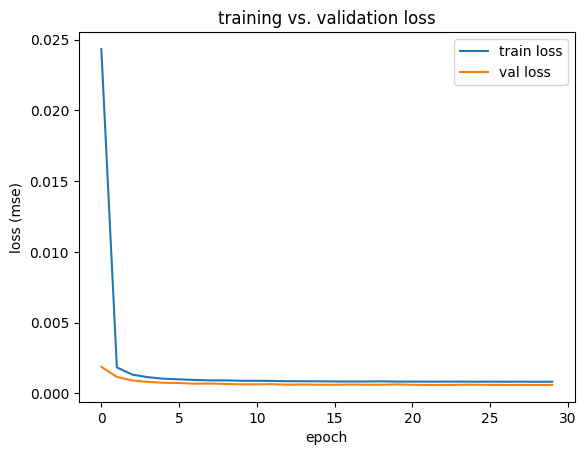

In [10]:
# plot train vs test accuracy
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss (mse)")
plt.legend()
plt.title("training vs. validation loss")
plt.show()

In [19]:
# try a more robust model (lstm)

# helper to build sequences for lsmt input
feature_cols = ["1d_log_return", "5d_log_return", "rsi", "5d_volatility", "relvol"]

# next-day return per ticker, computed once up front (`df` doesn't have this yet)
df["target_next_ret"] = df.groupby("ticker")["1d_log_return"].shift(-1)

def make_sequences(df, ticker, feature_cols, target_col="target_next_ret"):
    stock_df = df[df["ticker"] == ticker].sort_values("Date").dropna(subset=feature_cols + [target_col])
    X, y, dates = [], [], []
    values = stock_df[feature_cols].values
    targets = stock_df[target_col].values
    for i in range(10, len(stock_df)):
        X.append(values[i-10:i])       # last `window` days of features
        y.append(targets[i-1])             # target aligned with the last day in the window
        dates.append(stock_df["Date"].iloc[i-1])
    return np.array(X), np.array(y), dates

# create sequences
all_X, all_y, all_dates = [], [], []
for t in it_sector_cp['Symbol']:
    X_t, y_t, dates_t = make_sequences(df, t, feature_cols)
    all_X.append(X_t)
    all_y.append(y_t)
    all_dates.extend(dates_t)

# flatten data
X = np.concatenate(all_X)
y = np.concatenate(all_y)

# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# build the model
model = keras.Sequential([
    keras.layers.LSTM(24, input_shape=(10, len(feature_cols))),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)   
])
model.compile(optimizer="adam", loss="mse")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
) 

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


864/864 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0011 - val_loss: 8.1343e-04
Epoch 2/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.2486e-04 - val_loss: 8.4007e-04
Epoch 3/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 8.3481e-04 - val_loss: 8.1130e-04
Epoch 4/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.2317e-04 - val_loss: 8.1440e-04
Epoch 5/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.4131e-04 - val_loss: 7.8742e-04
Epoch 6/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.3416e-04 - val_loss: 8.3732e-04
Epoch 7/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.2393e-04 - val_loss: 7.6601e-04
Epoch 8/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.2118e-04 - val_loss: 7.7725e-04
Epoch 9/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.3059e-04 - val_loss: 8.1625e-04
Epoch 10/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.3367e-04 - val_loss: 7.6857e-04
Epoch 11/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.2532e-04 -

In [20]:
# compare are results against a trivial baseline
model_preds = model.predict(X_test).flatten()
baseline_pred = np.full_like(y_test, y_train.mean())

# compute mse and mae
model_mse = np.mean((model_preds - y_test) ** 2)
model_mae = np.mean(np.abs(model_preds - y_test))
baseline_mse = np.mean((baseline_pred - y_test) ** 2)
baseline_mae = np.mean(np.abs(baseline_pred - y_test))

# print resulst
print(f"model. mse: {model_mse}  mae: {model_mae}")
print(f"baseline. mse: {baseline_mse}  mae: {baseline_mae}")

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
model. mse: 0.0007680644293178474  mae: 0.01907187793089814
baseline. mse: 0.0007662003265523811  mae: 0.018944514462824528


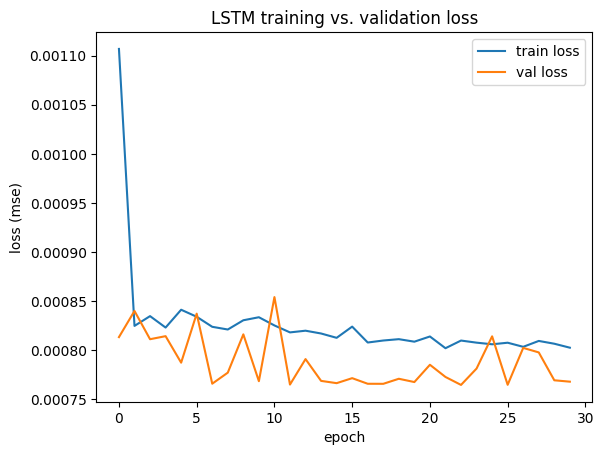

In [21]:
# plot LSTM training vs. validation loss over epochs
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss (mse)")
plt.legend()
plt.title("LSTM training vs. validation loss")
plt.show()

In [ ]:
# try to classify stock direction

# binary target: did the stock go up (1) or down/flat (0) the next day
df["target_next_dir"] = (df["target_next_ret"] > 0).astype(int)

# build sequences per ticker, reusing make_sequences with the binary target column
all_X_clf, all_y_clf = [], []
for t in it_sector_cp['Symbol']:
    X_t, y_t, _ = make_sequences(df, t, feature_cols, target_col="target_next_dir")
    all_X_clf.append(X_t)
    all_y_clf.append(y_t)

# flatten into datasets
X_clf = np.concatenate(all_X_clf)
y_clf = np.concatenate(all_y_clf)

# split the dataset
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, shuffle=False
)

# rebuild the LSTM as a binary classifier 
clf_model = keras.Sequential([
    keras.Input(shape=(10, len(feature_cols))),
    keras.layers.LSTM(24),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
clf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
clf_history = clf_model.fit(
    X_train_clf, y_train_clf,
    validation_data=(X_test_clf, y_test_clf),
    epochs=30,
    batch_size=32,
)

Epoch 1/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5193 - loss: 0.6927 - val_accuracy: 0.5189 - val_loss: 0.6935
Epoch 2/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5232 - loss: 0.6924 - val_accuracy: 0.5186 - val_loss: 0.6926
Epoch 3/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5222 - loss: 0.6924 - val_accuracy: 0.5189 - val_loss: 0.6926
Epoch 4/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5217 - loss: 0.6922 - val_accuracy: 0.5189 - val_loss: 0.6926
Epoch 5/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5240 - loss: 0.6922 - val_accuracy: 0.5189 - val_loss: 0.6927
Epoch 6/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5245 - loss: 0.6921 - val_accuracy: 0.5189 - val_loss: 0.6927
Epoch 7/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5250 - loss: 0.6922 - val_accuracy: 0.5189 - val_loss: 0.6927
Epoch 8/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5249 - loss: 0.6921 - val_accuracy: 0

In [25]:
# compare against a trivial baseline: always predict the majority class
clf_probs = clf_model.predict(X_test_clf).flatten()
clf_preds = (clf_probs > 0.5).astype(int)
clf_acc = np.mean(clf_preds == y_test_clf)

majority_class = int(round(y_train_clf.mean()))
baseline_preds_clf = np.full_like(y_test_clf, majority_class)
baseline_acc_clf = np.mean(baseline_preds_clf == y_test_clf)

print(f"model accuracy: {clf_acc}")
print(f"baseline accuracy: {baseline_acc_clf}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
model accuracy: 0.5185881672211775
baseline accuracy: 0.5188774772168379


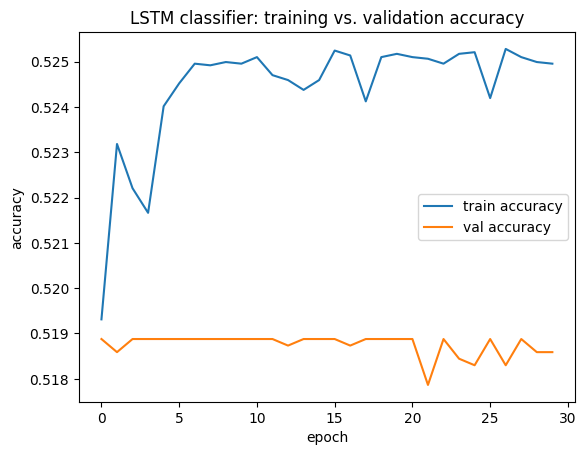

In [26]:
# plot classifier training vs. validation accuracy over epochs
plt.plot(clf_history.history["accuracy"], label="train accuracy")
plt.plot(clf_history.history["val_accuracy"], label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("LSTM classifier: training vs. validation accuracy")
plt.show()

In [32]:
# same model but with dropout
clf_model_dropout = keras.Sequential([
    keras.Input(shape=(10, len(feature_cols))),
    keras.layers.LSTM(24, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
clf_model_dropout.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
clf_history_dropout = clf_model_dropout.fit(
    X_train_clf, y_train_clf,
    validation_data=(X_test_clf, y_test_clf),
    epochs=30,
    batch_size=32,
)

Epoch 1/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5153 - loss: 0.6953 - val_accuracy: 0.5189 - val_loss: 0.6927
Epoch 2/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5189 - loss: 0.6931 - val_accuracy: 0.5189 - val_loss: 0.6940
Epoch 3/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5194 - loss: 0.6927 - val_accuracy: 0.5189 - val_loss: 0.6927
Epoch 4/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5210 - loss: 0.6928 - val_accuracy: 0.5189 - val_loss: 0.6930
Epoch 5/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5225 - loss: 0.6924 - val_accuracy: 0.4804 - val_loss: 0.6936
Epoch 6/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5218 - loss: 0.6921 - val_accuracy: 0.5189 - val_loss: 0.6925
Epoch 7/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5242 - loss: 0.6922 - val_accuracy: 0.5189 - val_loss: 0.6935
Epoch 8/30
865/865 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5234 - loss: 0.6924 - v

In [33]:
# compare dropout model against the no-dropout model and the trivial baseline
dropout_probs = clf_model_dropout.predict(X_test_clf).flatten()
dropout_preds = (dropout_probs > 0.5).astype(int)
dropout_acc = np.mean(dropout_preds == y_test_clf)

print(f"dropout model accuracy: {dropout_acc}")
print(f"no-dropout model accuracy: {clf_acc}")
print(f"baseline accuracy: {baseline_acc_clf}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
dropout model accuracy: 0.5188774772168379
no-dropout model accuracy: 0.5185881672211775
baseline accuracy: 0.5188774772168379


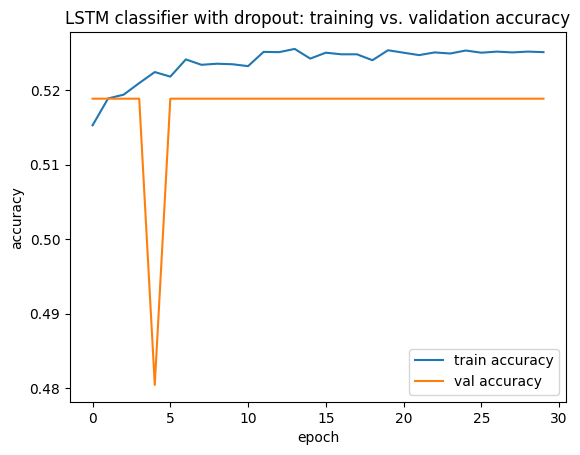

In [34]:
# plot dropout model's training vs. validation accuracy over epochs
plt.plot(clf_history_dropout.history["accuracy"], label="train accuracy")
plt.plot(clf_history_dropout.history["val_accuracy"], label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("LSTM classifier with dropout: training vs. validation accuracy")
plt.show()